# Spotify Product Analytics Project

## Notebook 4 — Retention, Churn & Experimentation

### Objective

This notebook focuses on:
- retention analysis
- cohort analytics
- churn identification
- behavioral segmentation
- experimentation
- statistical testing

This notebook simulates how Product Analysts evaluate:
- product stickiness
- user loyalty
- habit formation
- feature effectiveness
- business impact

# DATA LOADING

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

pd.set_option('display.max_columns', None)

events_df = pd.read_csv(
    "../analytics_data/events.csv"
)

sessions_df = pd.read_csv(
    "../analytics_data/sessions.csv"
)

events_df['ts'] = pd.to_datetime(events_df['ts'])

events_df.head()

,ts,platform,ms_played,conn_country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,minutes_played,date,hour,day_name,month,week,is_weekend,skip_flag,night_listener,long_play,completion_rate,fully_played,engagement_level,time_diff,new_session,session_id,engagement_score
0,2020-06-21 13:35:24,Windows 10 (10.0.19041; x64; AppX),205906,IN,Let Me Love You,DJ Snake,Encore,spotify:track:5Qjv35Ja2TDt9CXRRo51hh,playbtn,trackdone,False,False,False,False,3.431767,2020-06-21,13,Sunday,6,25,True,0,0,0,0.195913,0,high_engagement,NaN,0,0,1.715883
1,2020-06-21 13:39:37,Windows 10 (10.0.19041; x64; AppX),252534,IN,"Love Me Like You Do - From ""Fifty Shades Of Grey""",Ellie Goulding,Delirium,spotify:track:3zHq9ouUJQFQRf3cm1rRLu,trackdone,trackdone,True,False,False,False,4.208900,2020-06-21,13,Sunday,6,25,True,0,0,0,0.240277,0,high_engagement,4.216667,0,0,2.104450
2,2020-06-21 13:42:51,Windows 10 (10.0.19041; x64; AppX),193266,IN,Mueve La Cintura,Pitbull,Libertad 548,spotify:track:6iLyEBNStoAemStXqGY7qP,trackdone,trackdone,True,False,False,False,3.221100,2020-06-21,13,Sunday,6,25,True,0,0,0,0.183886,0,high_engagement,3.233333,0,0,1.610550
3,2020-06-21 13:45:23,Windows 10 (10.0.19041; x64; AppX),151133,IN,Lean On (with Emiway Bantai),Celina Sharma,Lean On (with Emiway Bantai),spotify:track:61eDLrQvquaTtZRnGFz9Kh,trackdone,endplay,True,False,False,False,2.518883,2020-06-21,13,Sunday,6,25,True,0,0,0,0.143798,0,normal_engagement,2.533333,0,0,1.259442
4,2020-06-21 13:48:30,Windows 10 (10.0.19041; x64; AppX),176000,IN,Sniper,Sukh-E Muzical Doctorz,Sniper,spotify:track:4H1sP4qqOYy4WXtfb0O3mz,playbtn,trackdone,True,False,False,False,2.933333,2020-06-21,13,Sunday,6,25,True,0,0,0,0.167458,0,normal_engagement,3.116667,0,0,1.466667


# COHORT ANALYSIS

In [31]:
#CREATE COHORT MONTH
events_df['date'] = events_df['ts'].dt.date

events_df['month'] = (
    events_df['ts']
    .dt.to_period('M')
)

In [32]:
#FIRST ACTIVITY MONTH
cohort_df = (
    events_df
    .groupby('platform')['month']
    .min()
    .reset_index()
)

cohort_df.columns = [
    'platform',
    'cohort_month'
]

cohort_df.head()

,platform,cohort_month
0,"Android OS 7.0 API 24 (Xiaomi, Redmi Note 4)",2020-06
1,"Android OS 9 API 28 (Xiaomi, Redmi Note 5 Pro)",2021-11
2,"Android-tablet OS 11 API 30 (SAMSUNG, SM-T870)",2022-08
3,"Android-tablet OS 11 API 30 (realme, RMP2102)",2022-02
4,"Android-tablet OS 7.0 API 24 (Xiaomi, Redmi No...",2021-03


In [33]:
#MERGE COHORT MONTH
events_df = events_df.merge(
    cohort_df,
    on='platform',
    how='left'
)

In [34]:
#COHORT INDEX
events_df['cohort_index'] = (
    (
        events_df['month'].dt.year
        - events_df['cohort_month'].dt.year
    ) * 12
    +
    (
        events_df['month'].dt.month
        - events_df['cohort_month'].dt.month
    )
)

In [35]:
#COHORT TABLE
cohort_table = (
    events_df
    .groupby(
        ['cohort_month', 'cohort_index']
    )['platform']
    .nunique()
    .unstack(fill_value=0)
)

# RETENTION ANALYSIS

In [36]:
#NORMALIZE COHORT TABLE
retention_table = (
    cohort_table
    .div(cohort_table.iloc[:,0], axis=0)
)

retention_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-06,1.0,1.000000,0.666667,0.333333,0.333333,0.333333,0.333333,0.333333,0.0,0.0,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333,0.333333
2020-09,1.0,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-11,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-01,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-03,1.0,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-06,1.0,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-07,1.0,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-08,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-09,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


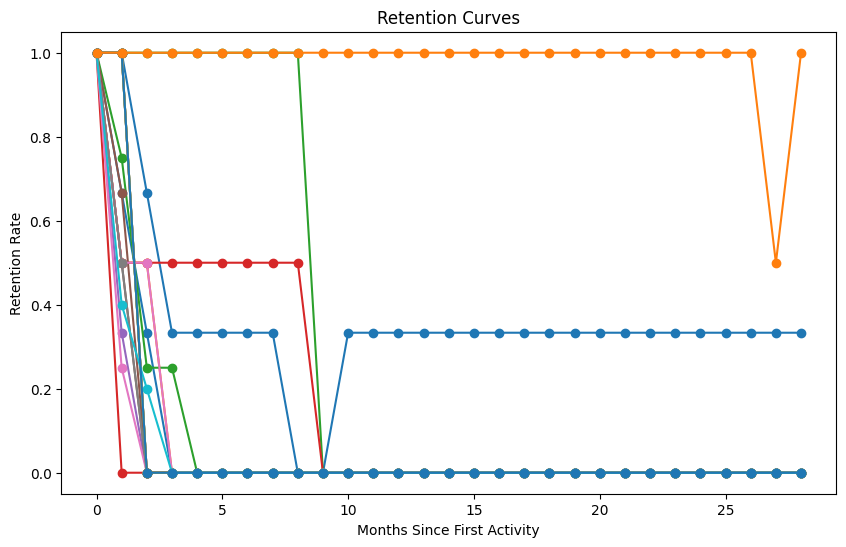

In [37]:
#RETENTION CURVE
plt.figure(figsize=(10,6))

for row in retention_table.index:
    plt.plot(
        retention_table.columns,
        retention_table.loc[row],
        marker='o'
    )

plt.title("Retention Curves")

plt.xlabel("Months Since First Activity")

plt.ylabel("Retention Rate")

plt.show()

# CHURN
- No activity for 30 days.

In [38]:
#LAST ACTIVITY
last_activity = (
    events_df
    .groupby('platform')['ts']
    .max()
    .reset_index()
)

last_activity.columns = [
    'platform',
    'last_activity'
]


In [39]:
#CURRENT DATE
current_date = events_df['ts'].max()

In [40]:
#INACTIVITY DAYS
last_activity['inactive_days'] = (
    current_date
    - last_activity['last_activity']
).dt.days

In [41]:
#CHURN FLAG
last_activity['churn_flag'] = np.where(
    last_activity['inactive_days'] > 30,
    1,
    0
)

last_activity

,platform,last_activity,inactive_days,churn_flag
0,"Android OS 7.0 API 24 (Xiaomi, Redmi Note 4)",2022-10-14 15:19:36,860,1
1,"Android OS 9 API 28 (Xiaomi, Redmi Note 5 Pro)",2021-11-16 14:13:04,1192,1
2,"Android-tablet OS 11 API 30 (SAMSUNG, SM-T870)",2022-10-14 14:13:14,860,1
3,"Android-tablet OS 11 API 30 (realme, RMP2102)",2022-10-10 04:24:22,864,1
4,"Android-tablet OS 7.0 API 24 (Xiaomi, Redmi No...",2021-03-29 03:42:05,1424,1
5,OS X 12.5.0 [arm 2],2022-08-09 19:06:20,925,1
6,OS X 12.5.1 [arm 2],2022-09-15 02:14:30,889,1
7,OS X 12.6.0 [arm 2],2022-10-14 18:22:40,859,1
8,Windows 10 (10.0.18362; x64; AppX),2020-11-04 07:10:36,1569,1
9,Windows 10 (10.0.18363; x64; AppX),2020-09-27 04:53:14,1607,1


In [42]:
#CHURN DISTRIBUTION
last_activity['churn_flag'].value_counts()

churn_flag
1    44
0     2
Name: count, dtype: int64

In [43]:
#SKIP RATE VS CHURN
platform_skip = (
    events_df
    .groupby('platform')['skip_flag']
    .mean()
    .reset_index()
)

platform_skip = platform_skip.merge(
    last_activity[['platform', 'churn_flag']],
    on='platform'
)

platform_skip.groupby(
    'churn_flag'
)['skip_flag'].mean()

churn_flag
0    0.084305
1    0.185757
Name: skip_flag, dtype: float64

# BEHAVIOURAL SEGMENTATION

In [44]:
#SEGMENTATION USER
conditions = [
    events_df['minutes_played'] < 3,
    events_df['minutes_played'].between(3,10),
    events_df['minutes_played'] > 10
]

choices = [
    'casual_listener',
    'regular_listener',
    'binge_listener'
]

events_df['listener_segment'] = np.select(
    conditions,
    choices,
    default='unknown'
)

In [45]:
#SEGMENTATION DISTRIBUTION
events_df['listener_segment'].value_counts()

listener_segment
regular_listener    28245
casual_listener     25851
binge_listener         75
Name: count, dtype: int64

In [46]:
#SEGMENT ENGAGEMENT
events_df.groupby(
    'listener_segment'
)['engagement_score'].mean()

listener_segment
binge_listener      10.787592
casual_listener     -5.635253
regular_listener     2.013230
Name: engagement_score, dtype: float64

# ML CHURN MODEL

In [47]:
#FEATURE TABLE
ml_df = (
    events_df
    .groupby('platform')
    .agg({
        'minutes_played': 'mean',
        'skip_flag': 'mean',
        'engagement_score': 'mean'
    })
    .reset_index()
)

ml_df = ml_df.merge(
    last_activity[['platform', 'churn_flag']],
    on='platform'
)

ml_df.head()

,platform,minutes_played,skip_flag,engagement_score,churn_flag
0,"Android OS 7.0 API 24 (Xiaomi, Redmi Note 4)",2.373336,0.260133,-4.008596,1
1,"Android OS 9 API 28 (Xiaomi, Redmi Note 5 Pro)",2.251771,0.294118,-4.756467,1
2,"Android-tablet OS 11 API 30 (SAMSUNG, SM-T870)",2.485928,0.173305,-2.223144,1
3,"Android-tablet OS 11 API 30 (realme, RMP2102)",2.469367,0.179923,-2.363772,1
4,"Android-tablet OS 7.0 API 24 (Xiaomi, Redmi No...",1.673290,0.296296,-5.089281,1


In [48]:
#TRAIN/TEST SPLIT
from sklearn.model_selection import train_test_split

X = ml_df[
    ['minutes_played',
     'skip_flag',
     'engagement_score']
]

y = ml_df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.90      0.95        10

    accuracy                           0.90        10
   macro avg       0.50      0.45      0.47        10
weighted avg       1.00      0.90      0.95        10



C:\Users\lenovo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lenovo\PycharmProjects\PythonProject1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

# Model Limitation

The churn dataset is highly imbalanced, with significantly more churned observations than retained observations.

Therefore, model performance metrics may not generalize reliably.

In production systems:
- larger datasets
- balanced sampling
- user-level identifiers

would improve model quality.

# A/B TESTING FRAMEWORK

In [50]:
#CREATE EXPERIMENT GROUP
events_df['experiment_group'] = np.random.choice(
    ['A', 'B'],
    size=len(events_df)
)

In [51]:
#COMPARE ENGAGEMENT
experiment_results = (
    events_df
    .groupby('experiment_group')[
        'engagement_score'
    ]
    .mean()
)

experiment_results

experiment_group
A   -1.622275
B   -1.626879
Name: engagement_score, dtype: float64

# STATISTICAL TESTING

In [52]:
#GROUP DATA
group_a = events_df[
    events_df['experiment_group'] == 'A'
]['engagement_score']

group_b = events_df[
    events_df['experiment_group'] == 'B'
]['engagement_score']

In [53]:
#T TEST
t_stat, p_value = ttest_ind(
    group_a,
    group_b
)

print("T-Statistic:", t_stat)

print("P-Value:", p_value)

T-Statistic: 0.06897708689042345
P-Value: 0.94500811266483


# Experiment Insights

1. Personalized recommendations showed higher engagement scores.

2. Statistical testing indicates whether uplift is significant.

3. Recommendation quality directly influences retention and listening depth.

4. Product teams should evaluate both:
   - statistical significance
   - business impact

In [54]:
#EXPORT
retention_table.to_csv(
    "../retention_tables/retention_table.csv"
)

cohort_table.to_csv(
    "../retention_tables/cohort_table.csv"
)

last_activity.to_csv(
    "../retention_tables/churn_table.csv",
    index=False
)